In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [53]:
data = pd.read_csv('C:/Users/KIMO STORE/Downloads/hotelBookings/cleaned_hotel_bookings_updated_2024.csv')
guests = pd.read_csv('C:/Users/KIMO STORE/Downloads/guests.csv/guests_data.csv')

In [54]:
df = pd.concat([data, guests], axis=1)

In [55]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city,name,email,phone-number,credit_card
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,...,0.0,0,0,Check-Out,2024-07-27 22:16:40.916332324,Chandigarh,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,...,0.0,0,0,Check-Out,2024-04-28 21:56:21.507509066,Mumbai,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,...,75.0,0,0,Check-Out,2024-09-10 03:46:25.734029096,Delhi,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,...,75.0,0,0,Check-Out,2024-08-14 18:07:10.049669568,Kolkata,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,...,98.0,0,1,Check-Out,2024-09-14 14:27:32.473846000,Lucknow,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 37 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [57]:
print(df.isnull().sum())

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [58]:
print(df['hotel'].unique())

['Resort Hotel - Chandigarh' 'Resort Hotel - Mumbai'
 'Resort Hotel - Delhi' 'Resort Hotel - Kolkata' 'Resort Hotel - Lucknow'
 'Resort Hotel - Indore' 'Resort Hotel - Ahmedabad' 'Resort Hotel - Pune'
 'Resort Hotel - Chennai' 'Resort Hotel - Bhopal'
 'Resort Hotel - Hyderabad' 'Resort Hotel - Kochi'
 'Resort Hotel - Bangalore' 'Resort Hotel - Jaipur' 'Resort Hotel - Goa'
 'City Hotel - Ahmedabad' 'City Hotel - Indore' 'City Hotel - Jaipur'
 'City Hotel - Pune' 'City Hotel - Hyderabad' 'City Hotel - Bhopal'
 'City Hotel - Kolkata' 'City Hotel - Mumbai' 'City Hotel - Bangalore'
 'City Hotel - Lucknow' 'City Hotel - Chennai' 'City Hotel - Chandigarh'
 'City Hotel - Delhi' 'City Hotel - Kochi' 'City Hotel - Goa']


In [59]:
#splitting hotel column
df['hotel'] = df['hotel'].str.split(' - ').str[0]
print(df['hotel'].unique())

['Resort Hotel' 'City Hotel']


In [60]:
print(f"repeated coloumns: {df.duplicated().sum()}")

repeated coloumns: 0


In [61]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

In [62]:
print(df['children'])

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
119385    0.0
119386    0.0
119387    0.0
119388    0.0
119389    0.0
Name: children, Length: 119390, dtype: float64


In [63]:
df['children'] = df['children'].astype(int)

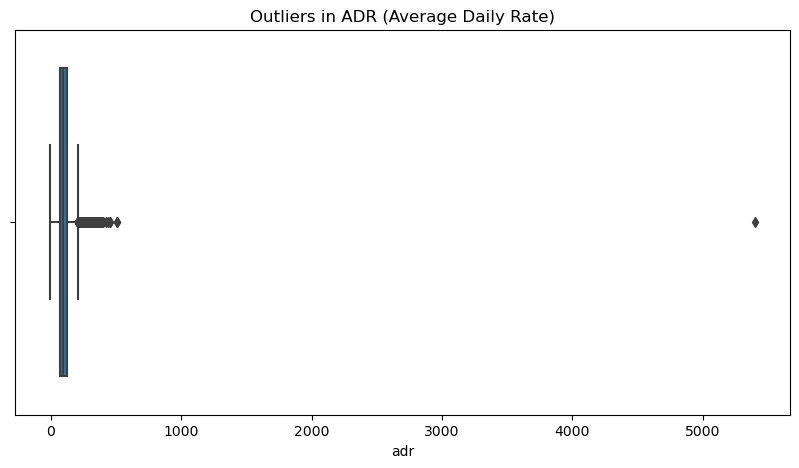

In [64]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['adr'])
plt.title('Outliers in ADR (Average Daily Rate)')
plt.show()

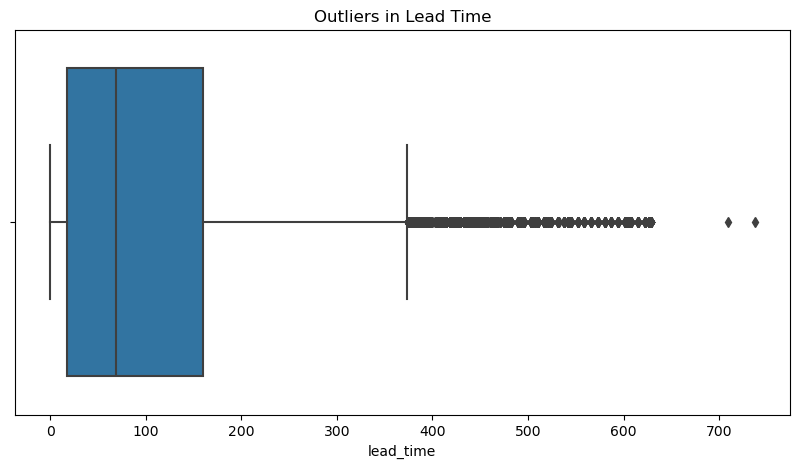

In [65]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['lead_time'])
plt.title('Outliers in Lead Time')
plt.show()

In [66]:
# removing outliers
df = df[df['adr'] < 5000]

# removing negative values
df = df[df['adr'] >= 0]

In [67]:
# reservations without people
no_guests = df[(df.adults + df.babies + df.children) == 0]
print(no_guests['is_canceled'].value_counts())

is_canceled
0    155
1     25
Name: count, dtype: int64


In [68]:
df = df.drop(df[(df.adults + df.babies + df.children) == 0].index)

In [69]:
print(f"remaining rows: {len(df)}")

remaining rows: 119208


D:\python\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


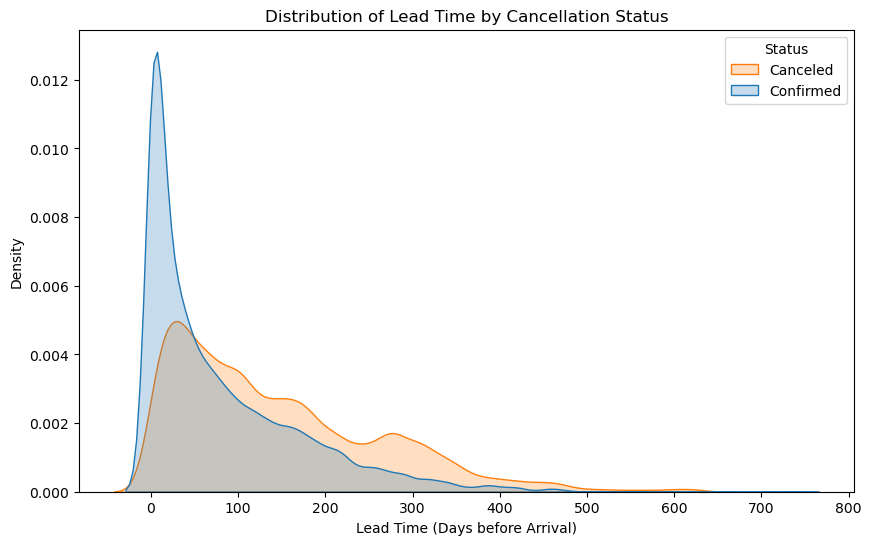

In [70]:
# Analysis of Lead Time vs. Cancellation Status
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='lead_time', hue='is_canceled', fill=True, common_norm=False)
plt.title('Distribution of Lead Time by Cancellation Status')
plt.xlabel('Lead Time (Days before Arrival)')
plt.ylabel('Density')
plt.legend(title='Status', labels=['Canceled', 'Confirmed'])
plt.show()

In [71]:
df['agent']

0          14.0
1          14.0
2          14.0
3         304.0
4         240.0
          ...  
119385    394.0
119386      9.0
119387      9.0
119388     89.0
119389      9.0
Name: agent, Length: 119208, dtype: float64

In [72]:
# inconsistent distribution channel
inconsistent_direct = df[(df['distribution_channel'] == 'Direct') & ((df['agent'] != 0) | (df['company'] != 0))]
print(f"inconsistents: {len(inconsistent_direct)}")

inconsistents: 14610


In [73]:
# 1. Fix Direct: No agent, No company
df.loc[df['distribution_channel'] == 'Direct', ['agent', 'company']] = 0

# 2. Fix Corporate: Usually has a company but no agent
# We only zero out the agent if it's a Corporate booking
df.loc[df['distribution_channel'] == 'Corporate', 'agent'] = 0
# Removing the 5 'Undefined' distribution channels
df = df[df['distribution_channel'] != 'Undefined']

# 3. Final Check: See the distribution now
print(df['distribution_channel'].value_counts())

distribution_channel
TA/TO        97749
Direct       14610
Corporate     6651
GDS            193
Name: count, dtype: int64


In [74]:
# Convert float columns to integer
df['agent'] = df['agent'].astype(int)
df['company'] = df['company'].astype(int)
df['children'] = df['children'].astype(int)

# Check the final types to be sure
print(df[['agent', 'company', 'children']].dtypes)

agent       int32
company     int32
children    int32
dtype: object


In [75]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,119203.000000,119203.000000,119203.0,119203.000000,119203.000000,119203.000000,119203.000000,119203.000000,119203.000000,119203.000000,...,119203.000000,119203.000000,119203.000000,119203.000000,119203.000000,119203.000000,119203.000000,119203.000000,119203.000000,119203
mean,0.370746,104.112447,2024.0,26.374605,15.722817,0.927032,2.499182,1.859190,0.104041,0.007961,...,0.087196,0.137085,0.218786,65.843787,157.619573,2.321351,101.927893,0.062549,0.571479,2024-07-01 01:20:23.723415808
min,0.000000,0.000000,2024.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2024-01-01 00:00:00
25%,0.000000,18.000000,2024.0,13.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,3.000000,179.000000,0.000000,69.500000,0.000000,0.000000,2024-03-31 21:21:36.933553408
50%,0.000000,69.000000,2024.0,26.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,9.000000,179.000000,0.000000,94.950000,0.000000,0.000000,2024-07-01 00:48:37.896958720
75%,1.000000,161.000000,2024.0,39.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,86.000000,179.000000,0.000000,126.000000,0.000000,1.000000,2024-09-30 08:30:59.266766592
max,1.000000,737.000000,2024.0,52.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,...,26.000000,72.000000,18.000000,531.000000,543.000000,391.000000,510.000000,8.000000,5.000000,2024-12-31 00:00:00
std,0.483007,106.876470,0.0,15.020072,8.804515,0.995086,1.897100,0.575192,0.398838,0.097512,...,0.844943,1.498171,0.638497,101.910010,65.984844,17.598510,48.041248,0.245351,0.792871,NaN


In [76]:
# 1. fix no Adults
df = df[df['adults'] > 0]

# 2. fix adr<0
df = df[df['adr'] > 0]

In [77]:
# mapping is_canceled column
df['is_canceled'] = df['is_canceled'].map({0: 'Confirmed', 1: 'Canceled'})

In [78]:
# mapping meal column
meal_labels = {
    'BB': 'Bed & Breakfast',
    'HB': 'Half Board',
    'FB': 'Full Board',
    'SC': 'No Meal',
    'Undefined': 'No Meal'
}
df['meal'] = df['meal'].replace(meal_labels)

In [79]:
# mapping is_repeated_guest column
df['is_repeated_guest'] = df['is_repeated_guest'].map({0: 'New Guest', 1: 'Repeated Guest'})

In [80]:
# mapping country column
country_dict = {
    'PRT': 'Portugal', 'GBR': 'United Kingdom', 'FRA': 'France', 
    'ESP': 'Spain', 'DEU': 'Germany', 'ITA': 'Italy', 
    'IRL': 'Ireland', 'BEL': 'Belgium', 'BRA': 'Brazil', 'USA': 'United States'
}

df['country'] = df['country'].map(country_dict).fillna('Other Countries')

In [81]:
# mapping market_segment column
segment_map = {
    'Online TA': 'Online Travel Agent',
    'Offline TA/TO': 'Offline Travel Agent/Tour Operator',
    'Direct': 'Direct Booking',
    'Groups': 'Group Bookings',
    'Corporate': 'Corporate',
    'Complementary': 'Free/Complementary',
    'Aviation': 'Aviation Industry'
}

df['market_segment'] = df['market_segment'].map(segment_map).fillna(df['market_segment'])

# mapping distribution_channel column
channel_map = {
    'TA/TO': 'Travel Agent/Tour Operator',
    'Direct': 'Direct Channel',
    'GDS': 'Global Distribution System',
    'Corporate': 'Corporate Channel'
}

df['distribution_channel'] = df['distribution_channel'].map(channel_map).fillna(df['distribution_channel'])

In [82]:
# mapping reserved_room_type column
room_map = {
    'A': 'Standard Room',
    'D': 'Double Room',
    'E': 'Triple Room',
    'F': 'Family Suite',
    'G': 'Presidential Suite',
    'B': 'Twin Room',
    'C': 'Single Room',
    'H': 'Luxury Suite'
}

df['reserved_room_type'] = df['reserved_room_type'].map(room_map).fillna('Special Category')

In [83]:
# mapping assigned_room_type column
room_map = {
    'A': 'Standard Room',
    'D': 'Double Room',
    'E': 'Triple Room',
    'F': 'Family Suite',
    'G': 'Presidential Suite',
    'B': 'Twin Room',
    'C': 'Single Room',
    'H': 'Luxury Suite'
}

df['assigned_room_type'] = df['assigned_room_type'].map(room_map).fillna('Special Category')

In [84]:
# combine arrival_date
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' + 
    df['arrival_date_month'].astype(str) + '-' + 
    df['arrival_date_day_of_month'].astype(str)
)
print(df['arrival_date'].dtype)

datetime64[ns]


In [85]:
print(df['arrival_date'])

2        2024-09-10
3        2024-08-14
4        2024-09-14
5        2024-10-23
6        2024-01-07
            ...    
119385   2024-09-29
119386   2024-11-16
119387   2024-04-19
119388   2024-10-05
119389   2024-12-21
Name: arrival_date, Length: 117176, dtype: datetime64[ns]


In [86]:
# drop date columns
df.drop(['arrival_date_year', 'arrival_date_month', 'arrival_date_day_of_month', 'arrival_date_week_number'], axis=1, inplace=True)

df.head()

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city,name,email,phone-number,credit_card,arrival_date
2,Resort Hotel,Confirmed,7,0,1,1,0,0,Bed & Breakfast,United Kingdom,...,0,0,Check-Out,2024-09-10 03:46:25.734029096,Delhi,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734,2024-09-10
3,Resort Hotel,Confirmed,13,0,1,1,0,0,Bed & Breakfast,United Kingdom,...,0,0,Check-Out,2024-08-14 18:07:10.049669568,Kolkata,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677,2024-08-14
4,Resort Hotel,Confirmed,14,0,2,2,0,0,Bed & Breakfast,United Kingdom,...,0,1,Check-Out,2024-09-14 14:27:32.473846000,Lucknow,Linda Hines,LHines@verizon.com,713-226-5883,************5498,2024-09-14
5,Resort Hotel,Confirmed,14,0,2,2,0,0,Bed & Breakfast,United Kingdom,...,0,1,Check-Out,2024-10-23 04:39:14.025915284,Delhi,Jasmine Fletcher,JFletcher43@xfinity.com,190-271-6743,************9263,2024-10-23
6,Resort Hotel,Confirmed,0,0,2,2,0,0,Bed & Breakfast,Portugal,...,0,0,Check-Out,2024-01-07 03:46:27.905083382,Indore,Dylan Rangel,Rangel.Dylan@comcast.net,420-332-5209,************6994,2024-01-07


In [87]:
# adding is_upgraded & is_downgraded coulmns to compare between reserved_room_type & assigned_room_type
room_rank = {
    'Standard Room': 1,
    'Twin Room': 2,
    'Single Room': 3,
    'Double Room': 4,
    'Triple Room': 5,
    'Family Suite': 6,
    'Presidential Suite': 7,
    'Luxury Suite': 8,
    'Special Category': 0
}
res_rank = df['reserved_room_type'].map(room_rank)
asn_rank = df['assigned_room_type'].map(room_rank)
df['is_upgraded'] = (asn_rank > res_rank).astype(int)
df['is_downgraded'] = (asn_rank < res_rank).astype(int)

In [88]:
print(df['is_upgraded'].sum())

13213


In [89]:
print(df['is_downgraded'].sum())

837


In [90]:
df.head()

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,...,reservation_status,reservation_status_date,city,name,email,phone-number,credit_card,arrival_date,is_upgraded,is_downgraded
2,Resort Hotel,Confirmed,7,0,1,1,0,0,Bed & Breakfast,United Kingdom,...,Check-Out,2024-09-10 03:46:25.734029096,Delhi,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734,2024-09-10,1,0
3,Resort Hotel,Confirmed,13,0,1,1,0,0,Bed & Breakfast,United Kingdom,...,Check-Out,2024-08-14 18:07:10.049669568,Kolkata,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677,2024-08-14,0,0
4,Resort Hotel,Confirmed,14,0,2,2,0,0,Bed & Breakfast,United Kingdom,...,Check-Out,2024-09-14 14:27:32.473846000,Lucknow,Linda Hines,LHines@verizon.com,713-226-5883,************5498,2024-09-14,0,0
5,Resort Hotel,Confirmed,14,0,2,2,0,0,Bed & Breakfast,United Kingdom,...,Check-Out,2024-10-23 04:39:14.025915284,Delhi,Jasmine Fletcher,JFletcher43@xfinity.com,190-271-6743,************9263,2024-10-23,0,0
6,Resort Hotel,Confirmed,0,0,2,2,0,0,Bed & Breakfast,Portugal,...,Check-Out,2024-01-07 03:46:27.905083382,Indore,Dylan Rangel,Rangel.Dylan@comcast.net,420-332-5209,************6994,2024-01-07,0,0


In [91]:
# 1. (Duplicates)
duplicates_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicates_count}")

# 2. checking ADR 
print("\n--- ADR Analysis ---")
print(f"Minimum ADR: {df['adr'].min()}")
print(f"Maximum ADR: {df['adr'].max()}")
print(f"Zero ADR Count: {(df['adr'] == 0).sum()}")
print(f"Negative ADR Count: {(df['adr'] < 0).sum()}")

Total Duplicate Rows: 0

--- ADR Analysis ---
Minimum ADR: 0.26
Maximum ADR: 510.0
Zero ADR Count: 0
Negative ADR Count: 0


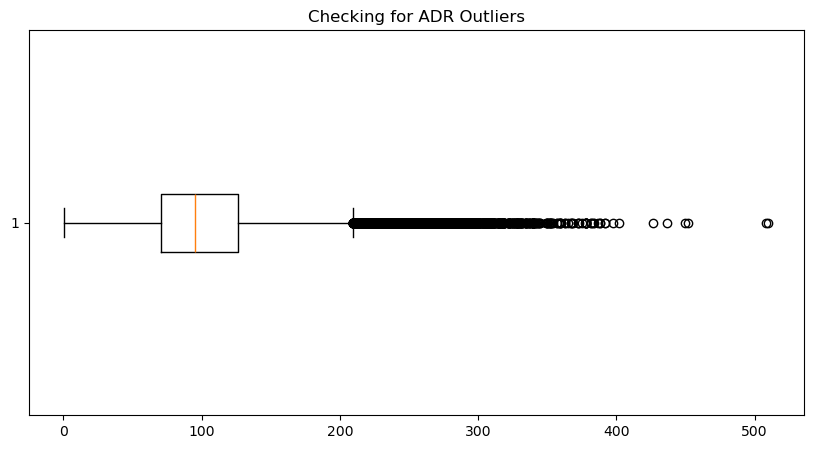

In [92]:
plt.figure(figsize=(10, 5))
plt.boxplot(df['adr'], vert=False)
plt.title("Checking for ADR Outliers")
plt.show()

In [93]:
df["previous_cancellations"].unique()

array([ 0,  1,  2,  3, 26, 25, 14,  4, 24, 19,  5, 21,  6, 13, 11],
      dtype=int64)

In [94]:
df["previous_bookings_not_canceled"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 19, 26, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72], dtype=int64)

In [95]:
#inconsistent_new_guest (new guest but has previous_cancellations or previous_bookings_not_canceled)
inconsistent_new_guest = df[
    (df['is_repeated_guest'] == 'New Guest') & 
    ((df['previous_cancellations'] > 0) | (df['previous_bookings_not_canceled'] > 0))
]

print(f"inconsistents : {len(inconsistent_new_guest)}")

inconsistents : 6188


In [96]:
len(df)

117176

In [97]:
# fixing inconsistent_new_guest
df.loc[(df['previous_cancellations'] > 0) | (df['previous_bookings_not_canceled'] > 0), 'is_repeated_guest'] = 'Repeated Guest'

In [98]:
personal_cols = ['name', 'email']

for col in personal_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

# 3. Specific Column Cleaning
# Clean phone numbers (keep only digits)
df['phone-number'] = df['phone-number'].str.replace(r'\D', '', regex=True)

# 4. Identifying Repeated Guests
# We count occurrences based on Email (the primary identifier)
df['email_occurrence'] = df.groupby('email')['email'].transform('count')

# Define Logic: More than 1 occurrence = Repeated Guest
df['is_repeated_guest'] = np.where(df['email_occurrence'] > 1, 'Repeated Guest', 'New Guest')

# 5. Data Quality Report
total_bookings = len(df)
unique_humans = df['email'].nunique()
repeated_humans = df[df['is_repeated_guest'] == 'Repeated Guest']['email'].nunique()
new_guests_count = unique_humans - repeated_humans

print("--- Final Data Quality Report ---")
print(f"Total Bookings (Rows): {total_bookings}")
print(f"Unique Human Beings: {unique_humans}")
print(f"Number of Loyal (Repeated) Guests: {repeated_humans}")
print(f"Number of First-time (New) Guests: {new_guests_count}")
df.drop(['email_occurrence'], axis=1, inplace=True)

--- Final Data Quality Report ---
Total Bookings (Rows): 117176
Unique Human Beings: 113807
Number of Loyal (Repeated) Guests: 2897
Number of First-time (New) Guests: 110910


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117176 entries, 2 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           117176 non-null  object        
 1   is_canceled                     117176 non-null  object        
 2   lead_time                       117176 non-null  int64         
 3   stays_in_weekend_nights         117176 non-null  int64         
 4   stays_in_week_nights            117176 non-null  int64         
 5   adults                          117176 non-null  int64         
 6   children                        117176 non-null  int32         
 7   babies                          117176 non-null  int64         
 8   meal                            117176 non-null  object        
 9   country                         117176 non-null  object        
 10  market_segment                  117176 non-null  object      

In [101]:
df.to_csv(r'C:\Users\KIMO STORE\Downloads\hotelBookings\Hotel_Booking_Final.csv', index=False)